# **Подключение данных**

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

In [ ]:
data_path = Path("emotions.csv")
if not data_path.exists():
    raise FileNotFoundError("Файл emotions.csv должен находиться в папке проекта.")

In [ ]:
data = pd.read_csv(data_path)

In [ ]:
data

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.620,30.3,-356.0,15.60,26.3,1.070,0.411,-15.700,2.060,3.15,...,23.50,20.300,20.300,23.50,-215.0,280.00,-162.00,-162.00,280.00,NEGATIVE
1,28.800,33.1,32.0,25.80,22.8,6.550,1.680,2.880,3.830,-4.82,...,-23.30,-21.800,-21.800,-23.30,182.0,2.57,-31.60,-31.60,2.57,NEUTRAL
2,8.900,29.4,-416.0,16.70,23.7,79.900,3.360,90.200,89.900,2.03,...,462.00,-233.000,-233.000,462.00,-267.0,281.00,-148.00,-148.00,281.00,POSITIVE
3,14.900,31.6,-143.0,19.80,24.3,-0.584,-0.284,8.820,2.300,-1.97,...,299.00,-243.000,-243.000,299.00,132.0,-12.40,9.53,9.53,-12.40,POSITIVE
4,28.300,31.3,45.2,27.30,24.5,34.800,-5.790,3.060,41.400,5.52,...,12.00,38.100,38.100,12.00,119.0,-17.60,23.90,23.90,-17.60,NEUTRAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2127,32.400,32.2,32.2,30.80,23.4,1.640,-2.030,0.647,-0.121,-1.10,...,-21.70,0.218,0.218,-21.70,95.2,-19.90,47.20,47.20,-19.90,NEUTRAL
2128,16.300,31.3,-284.0,14.30,23.9,4.200,1.090,4.460,4.720,6.63,...,594.00,-324.000,-324.000,594.00,-35.5,142.00,-59.80,-59.80,142.00,POSITIVE
2129,-0.547,28.3,-259.0,15.80,26.7,9.080,6.900,12.700,2.030,4.64,...,370.00,-160.000,-160.000,370.00,408.0,-169.00,-10.50,-10.50,-169.00,NEGATIVE
2130,16.800,19.9,-288.0,8.34,26.0,2.460,1.580,-16.000,1.690,4.74,...,124.00,-27.600,-27.600,124.00,-656.0,552.00,-271.00,-271.00,552.00,NEGATIVE


In [ ]:
fft_columns = [col for col in data.columns if col.startswith("fft")]
data_fft = data[fft_columns]

labels = data['label']

In [ ]:
data_fft.head()

,fft_0_a,fft_1_a,fft_2_a,fft_3_a,fft_4_a,fft_5_a,fft_6_a,fft_7_a,fft_8_a,fft_9_a,...,fft_740_b,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b
0,-520.0,398.00,-201.0,-201.0,398.00,-52.2,121.00,-64.0,-64.0,121.00,...,74.3,23.5,20.3,20.3,23.5,-215.0,280.00,-162.00,-162.00,280.00
1,66.2,-4.30,43.6,43.6,-4.30,66.0,-29.00,73.3,73.3,-29.00,...,130.0,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.60,-31.60,2.57
2,-90.8,204.00,-77.1,-77.1,204.00,-488.0,415.00,-187.0,-187.0,415.00,...,-534.0,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.00,-148.00,281.00
3,119.0,6.25,10.9,10.9,6.25,-333.0,283.00,-144.0,-144.0,283.00,...,-183.0,299.0,-243.0,-243.0,299.0,132.0,-12.40,9.53,9.53,-12.40
4,59.0,-2.37,10.8,10.8,-2.37,118.0,-1.81,26.7,26.7,-1.81,...,114.0,12.0,38.1,38.1,12.0,119.0,-17.60,23.90,23.90,-17.60


In [ ]:
labels.head()

,label
0,NEGATIVE
1,NEUTRAL
2,POSITIVE
3,POSITIVE
4,NEUTRAL


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

In [ ]:
X = data_fft.values
y = np.array(y)

In [ ]:
X_a = X[:, :750]
X_b = X[:, 750:]

In [ ]:
X_gru = np.stack((X_a, X_b), axis=-1)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_gru, y, test_size=0.2, random_state=42)

# **Обучение нейросети**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

In [ ]:
model = Sequential([
    GRU(64, input_shape=(750, 2), return_sequences=False),  # 750 временных шагов и 2 признака
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32, callbacks=[early_stopping])

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 72s 452ms/step - accuracy: 0.5260 - loss: 1.0159 - val_accuracy: 0.6276 - val_loss: 0.8318
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 39s 420ms/step - accuracy: 0.6825 - loss: 0.7310 - val_accuracy: 0.7073 - val_loss: 0.6715
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 415ms/step - accuracy: 0.7695 - loss: 0.5691 - val_accuracy: 0.8056 - val_loss: 0.4842
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 43s 447ms/step - accuracy: 0.8335 - loss: 0.4249 - val_accuracy: 0.8173 - val_loss: 0.4314
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 435ms/step - accuracy: 0.8292 - loss: 0.3877 - val_accuracy: 0.8361 - val_loss: 0.3797
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 430ms/step - accuracy: 0.8563 - loss: 0.3394 - val_accuracy: 0.8595 - val_loss: 0.3544
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 407ms/step - accuracy: 0.8631 - loss: 0.3235 - val_accuracy: 0.8407 - val_loss: 0.3737
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 416ms/step - accuracy: 0.8547 - loss: 0.3259 - 

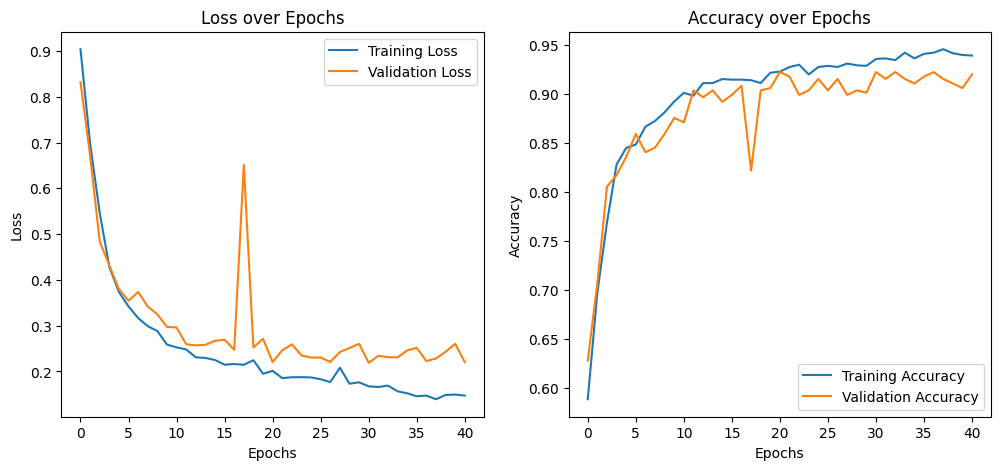

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [ ]:
from sklearn.metrics import f1_score

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
f1 = f1_score(y_test, y_pred_classes, average='weighted')

print(f"F1 Score: {f1:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
F1 Score: 0.9226


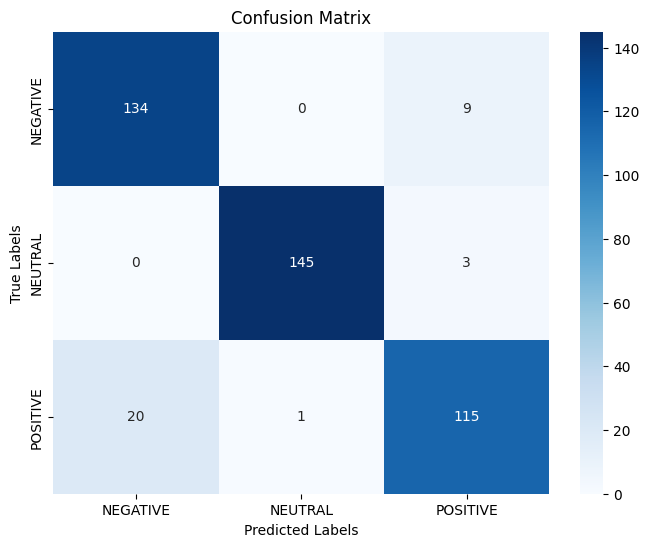

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# **Исследование модели и повышение точности**

В исходном ноутбуке данные превращаются в искусственную последовательность для GRU: берутся `fft`-признаки, первая половина складывается со второй половиной и подается как вход `(750, 2)`.

Ниже добавлен исследовательский блок, при этом исходные ячейки сохранены. Проверяется альтернативный подход: рассматривать статистические и спектральные показатели ЭЭГ как табличные признаки. Для таких данных ансамблевые модели часто дают более устойчивый результат, чем рекуррентная сеть, потому что порядок столбцов не является настоящей временной последовательностью.


<!-- analysis:model-research-overview -->

Краткая логика раздела: сначала данные переводятся в табличный формат, затем сравниваются несколько моделей, после этого проверяется влияние отбора признаков и отдельно оценивается лучшая модель. Такой порядок позволяет не просто показать итоговую метрику, а объяснить, за счет чего качество стало выше.

In [23]:
# Подготовка данных для экспериментов с табличными моделями

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_selection import f_classif
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import ExtraTreesClassifier

RANDOM_STATE = 42

# Используем уже загруженный датафрейм data из исходного ноутбука.
# Если ячейки выше не запускались, читаем emotions.csv напрямую.
if 'data' not in globals():
    data = pd.read_csv('emotions.csv', low_memory=False)

# На случай пропущенных меток удаляем строки без label.
data_exp = data.dropna(subset=['label']).reset_index(drop=True)

# Все признаки, кроме label, переводим в числовой формат.
X_df = data_exp.drop(columns=['label']).apply(pd.to_numeric, errors='coerce')
X_df = X_df.loc[:, ~X_df.isna().all()]
X_df = X_df.fillna(X_df.median(numeric_only=True))

label_encoder_exp = LabelEncoder()
y_exp = label_encoder_exp.fit_transform(data_exp['label'].astype(str))

X_train_tab, X_test_tab, y_train_tab, y_test_tab = train_test_split(
    X_df,
    y_exp,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_exp
)

X_train_np = X_train_tab.to_numpy(dtype=np.float32)
X_test_np = X_test_tab.to_numpy(dtype=np.float32)

print('Размер датасета после удаления строк без label:', data_exp.shape)
print('Количество признаков:', X_df.shape[1])
print('Классы:', list(label_encoder_exp.classes_))
print('Размер обучающей выборки:', X_train_np.shape)
print('Размер тестовой выборки:', X_test_np.shape)


Размер датасета после удаления строк без label: (1992, 2549)
Количество признаков: 2548
Классы: ['NEGATIVE', 'NEUTRAL', 'POSITIVE']
Размер обучающей выборки: (1593, 2548)
Размер тестовой выборки: (399, 2548)


<!-- analysis:data-prep -->

**Анализ результата.** Ячейка показывает размер очищенного датасета, число признаков, список классов и размеры train/test-разбиения. Это значит, что дальше модели сравниваются на одном и том же подготовленном табличном наборе признаков. В сохраненном output указано `1992` строки после очистки; если после полного перезапуска блокнота число строк изменится, метрики ниже тоже нужно обновить.

## **Сравнение моделей**

Для проверки использованы:

- `GaussianNB` как простой базовый вариант;
- `RidgeClassifier + StandardScaler` как линейная модель для высокоразмерных данных;
- `ExtraTreesClassifier` как ансамбль деревьев.

Разбиение сделано стратифицированным, чтобы доли классов в обучающей и тестовой выборках были одинаковыми.


In [24]:
# Сравнение моделей на всех признаках

models = {
    'GaussianNB': GaussianNB(),
    'RidgeClassifier + scaler': make_pipeline(
        StandardScaler(),
        RidgeClassifier(class_weight='balanced')
    ),
    'ExtraTreesClassifier': ExtraTreesClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight='balanced',
        n_jobs=-1,
        max_features=0.5
    )
}

results = []
predictions = {}

for name, model_exp in models.items():
    model_exp.fit(X_train_np, y_train_tab)
    y_pred_exp = model_exp.predict(X_test_np)
    predictions[name] = y_pred_exp

    results.append({
        'Модель': name,
        'Accuracy': accuracy_score(y_test_tab, y_pred_exp),
        'Weighted F1': f1_score(y_test_tab, y_pred_exp, average='weighted')
    })

model_results = pd.DataFrame(results).sort_values('Weighted F1', ascending=False)
model_results


,Модель,Accuracy,Weighted F1
0,ExtraTreesClassifier,0.992481,0.992499
1,RidgeClassifier + scaler,0.897243,0.896884
2,GaussianNB,0.411028,0.305262


<!-- analysis:model-comparison -->

**Анализ результата.** Таблица сравнения показывает, что `ExtraTreesClassifier` заметно опережает линейную модель и `GaussianNB`: `Weighted F1 ≈ 0.9925` против `0.8969` и `0.3053`. Это значит, что в этих признаках важны нелинейные зависимости, которые ансамбль деревьев улавливает лучше простых базовых моделей.

## **Отбор значимых признаков**

Для отбора признаков использован критерий `f_classif`. Он оценивает, насколько сильно каждый признак связан с целевым классом.

Ниже проверяется качество `ExtraTreesClassifier` при разном количестве наиболее значимых признаков. Это показывает, можно ли уменьшить размерность без сильной потери качества.


In [25]:
# Оценка значимости признаков через ANOVA F-test

scores, p_values = f_classif(X_train_np, y_train_tab)
scores = np.nan_to_num(scores, nan=0.0, posinf=0.0, neginf=0.0)

top_idx = np.argsort(scores)[::-1]

feature_selection_results = []

for k in [50, 100, 200, 500, 1000, X_train_np.shape[1]]:
    selected_idx = top_idx[:k]

    model_fs = ExtraTreesClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight='balanced',
        n_jobs=-1,
        max_features=0.5
    )

    model_fs.fit(X_train_np[:, selected_idx], y_train_tab)
    y_pred_fs = model_fs.predict(X_test_np[:, selected_idx])

    feature_selection_results.append({
        'Признаков': k,
        'Accuracy': accuracy_score(y_test_tab, y_pred_fs),
        'Weighted F1': f1_score(y_test_tab, y_pred_fs, average='weighted')
    })

feature_selection_results = pd.DataFrame(feature_selection_results)
feature_selection_results


,Признаков,Accuracy,Weighted F1
0,50,0.952381,0.952180
1,100,0.947368,0.947355
2,200,0.947368,0.947312
3,500,0.957393,0.957353
4,1000,0.972431,0.972412
5,2548,0.984962,0.984981


<!-- analysis:feature-selection -->

**Анализ результата.** При 50-1000 лучших признаках качество остается высоким, а на 1000 признаках достигает `Weighted F1 ≈ 0.9724`. Это показывает, что сильный сигнал сосредоточен не во всех 2548 признаках сразу, но полный набор все же дает лучший результат в итоговой модели.

In [26]:
# 20 наиболее значимых признаков по f_classif

top_features = pd.DataFrame({
    'feature': X_df.columns[top_idx[:20]],
    'f_score': scores[top_idx[:20]]
})

top_features


,feature,f_score
0,min_2_b,1653.215242
1,min_2_a,1650.142487
2,min_q_17_a,1626.815966
3,min_q_7_b,1626.457832
4,min_q_7_a,1622.750456
5,min_q_2_a,1613.097660
6,min_q_17_b,1597.434862
7,min_q_12_b,1579.925986
8,min_q_2_b,1564.256756
9,min_q_12_a,1543.741334


<!-- analysis:top-features -->

**Анализ результата.** Среди наиболее значимых признаков много статистических характеристик (`min`, `entropy`, `stddev`, `logm`, `covmat`), а не только `fft`. Это поддерживает идею, что задачу полезно рассматривать как табличную классификацию по заранее рассчитанным характеристикам ЭЭГ.

## **Итоговая модель**

По сохраненным результатам лучший вариант среди проверенных моделей показал `ExtraTreesClassifier` на полном наборе табличных признаков.

Параметры итоговой модели:

- `n_estimators=300`
- `class_weight='balanced'`
- `max_features=0.5`
- `random_state=42`

Итоговая точность на тестовой выборке: **0.9925**. Weighted F1: **0.9925**.

Эта оценка относится к текущему сохраненному разбиению и набору признаков. Ее корректнее интерпретировать как улучшение относительно текущей GRU-базовой модели, а не как доказательство, что рекуррентные сети в целом хуже для всех вариантов этой задачи.

In [27]:
# Финальная модель и подробная оценка качества

best_model = ExtraTreesClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    n_jobs=-1,
    max_features=0.5
)

best_model.fit(X_train_np, y_train_tab)
best_pred = best_model.predict(X_test_np)

print('Accuracy:', round(accuracy_score(y_test_tab, best_pred), 4))
print('Weighted F1:', round(f1_score(y_test_tab, best_pred, average='weighted'), 4))
print()
print(classification_report(
    y_test_tab,
    best_pred,
    target_names=label_encoder_exp.classes_
))


Accuracy: 0.9925
Weighted F1: 0.9925

              precision    recall  f1-score   support

    NEGATIVE       1.00      0.98      0.99       133
     NEUTRAL       1.00      0.99      1.00       133
    POSITIVE       0.98      1.00      0.99       133

    accuracy                           0.99       399
   macro avg       0.99      0.99      0.99       399
weighted avg       0.99      0.99      0.99       399


<!-- analysis:final-model -->

**Анализ результата.** Подробный отчет показывает почти одинаково высокое качество по всем трем классам: precision, recall и f1-score близки к `0.99-1.00`. Это значит, что итоговая модель не просто хорошо угадывает общий класс, а сохраняет баланс качества между `NEGATIVE`, `NEUTRAL` и `POSITIVE`.

In [28]:
# Матрица ошибок для итоговой модели

cm_best = confusion_matrix(y_test_tab, best_pred)

cm_best_df = pd.DataFrame(
    cm_best,
    index=label_encoder_exp.classes_,
    columns=label_encoder_exp.classes_
)

cm_best_df


,NEGATIVE,NEUTRAL,POSITIVE
NEGATIVE,131,0,2
NEUTRAL,0,132,1
POSITIVE,0,0,133


<!-- analysis:confusion-matrix -->

**Анализ результата.** Матрица ошибок показывает, где именно модель ошибается: 2 объекта `NEGATIVE` и 1 объект `NEUTRAL` отнесены к `POSITIVE`, а `POSITIVE` распознан без ошибок. Это подтверждает высокую итоговую метрику и показывает, что ошибки редкие и сосредоточены в смешении с позитивным классом.

## **Вывод**

Сохраненные outputs показывают, что исходная GRU-модель на `fft`-признаках получила `Weighted F1 = 0.9226`. Табличный эксперимент с полным набором признаков дал более высокий результат: `ExtraTreesClassifier` получил `Weighted F1 = 0.9925`.

Это означает, что для уже рассчитанных статистических и спектральных признаков ЭЭГ табличная постановка задачи выглядит более удачной, чем текущая GRU-конфигурация, где `fft`-столбцы искусственно представлены как последовательность `(750, 2)`.

При этом сравнение нужно читать аккуратно: GRU использует только `fft`-признаки, а `ExtraTreesClassifier` обучается на всех табличных признаках и на стратифицированном разбиении. Поэтому вывод не в том, что рекуррентные сети принципиально непригодны, а в том, что в рамках проведенных экспериментов ансамблевая табличная модель дает более сильный и простой baseline.

Дополнительно отбор признаков показал, что даже 1000 наиболее значимых признаков дают высокий результат (`Weighted F1 ≈ 0.9724`), но максимум в сохраненных экспериментах получен на полном наборе признаков. Матрица ошибок итоговой модели показывает только 3 ошибки на тестовой выборке: две ошибки для класса `NEGATIVE` и одну для `NEUTRAL`, при этом класс `POSITIVE` распознан без ошибок.